# 05b — ViT-B/16 Test Set Evaluation
**WikiArt Painting Classifier** — NOVA IMS Deep Learning 2025/2026

This notebook loads the trained ViT-B/16 model and evaluates it on the held-out **test set**. It produces:
1. Overall accuracy, loss, and **F1-macro** (primary metric).
2. Per-class precision, recall, and F1 via a classification report.
3. Normalised confusion matrix.
4. All figures saved to `results/figures/` for the report.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

sys.path.insert(0, os.path.abspath(".."))
from src.data_loader import build_datasets

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
MODEL_PATH = "../results/models/vit.keras"

## 1. Load Test Dataset and Trained Model

In [2]:
# Load datasets (we only need test_ds, but the function returns all three)
_, _, test_ds, NUM_CLASSES = build_datasets(
    splits_dir="../data/splits",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    augment_train=False,
    use_processed=True,
    processed_dir="../data/processed"
)

test_ds_oh = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))

# Load the artist names from the splits for labelling
test_df = pd.read_csv("../data/splits/test.csv", encoding="utf-8-sig")
artist_names = sorted(test_df["artist"].unique())
print(f"Test set: {len(test_df)} images, {NUM_CLASSES} classes")
print(f"Artists: {artist_names[:5]} ... ({len(artist_names)} total)")

Test set: 2002 images, 23 classes
Artists: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet'] ... (23 total)


In [3]:
# Load the trained model
model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded from {MODEL_PATH}")
print(f"Parameters: {model.count_params():,}")

c:\Users\Administrator\Documents\Master\DL\WikiArt-DeepLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Model loaded from ../results/models/vit.keras
Parameters: 85,816,343


## 2. Overall Test Metrics
Evaluate the model on the full test set to get loss, accuracy, and F1-macro.

In [4]:
# Evaluate with Keras (loss, accuracy, F1-macro)
results = model.evaluate(test_ds_oh, verbose=1)
metric_names = model.metrics_names

print("\n--- Test Set Results ---")
for name, value in zip(metric_names, results):
    print(f"  {name:15s}: {value:.4f}")

126/126 ━━━━━━━━━━━━━━━━━━━━ 69s 539ms/step - accuracy: 0.8282 - f1_macro: 0.8176 - loss: 0.5886

--- Test Set Results ---
  loss           : 0.5886
  compile_metrics: 0.8282


## 3. Per-class Classification Report
Compute precision, recall, and F1-score for each artist using scikit-learn.

In [5]:
# Collect true labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print(classification_report(y_true, y_pred, target_names=artist_names, digits=3))

                       precision    recall  f1-score   support

       Albrecht_Durer      0.860     0.851     0.855        87
      Boris_Kustodiev      0.687     0.687     0.687        67
     Camille_Pissarro      0.658     0.828     0.733        93
        Childe_Hassam      0.824     0.724     0.771        58
         Claude_Monet      0.854     0.793     0.822       140
          Edgar_Degas      0.724     0.859     0.786        64
        Eugene_Boudin      0.941     0.828     0.881        58
         Gustave_Dore      0.963     0.988     0.975        80
           Ilya_Repin      0.729     0.768     0.748        56
      Ivan_Aivazovsky      0.947     0.900     0.923        60
        Ivan_Shishkin      0.936     0.815     0.871        54
  John_Singer_Sargent      0.831     0.831     0.831        83
         Marc_Chagall      0.811     0.901     0.854        81
      Martiros_Saryan      0.671     0.817     0.737        60
     Nicholas_Roerich      0.894     0.885     0.889  

## 4. Confusion Matrix
Normalised confusion matrix showing prediction patterns across all 23 artists.

Figure saved to: ../results/figures/vit_confusion_matrix_normalised.png


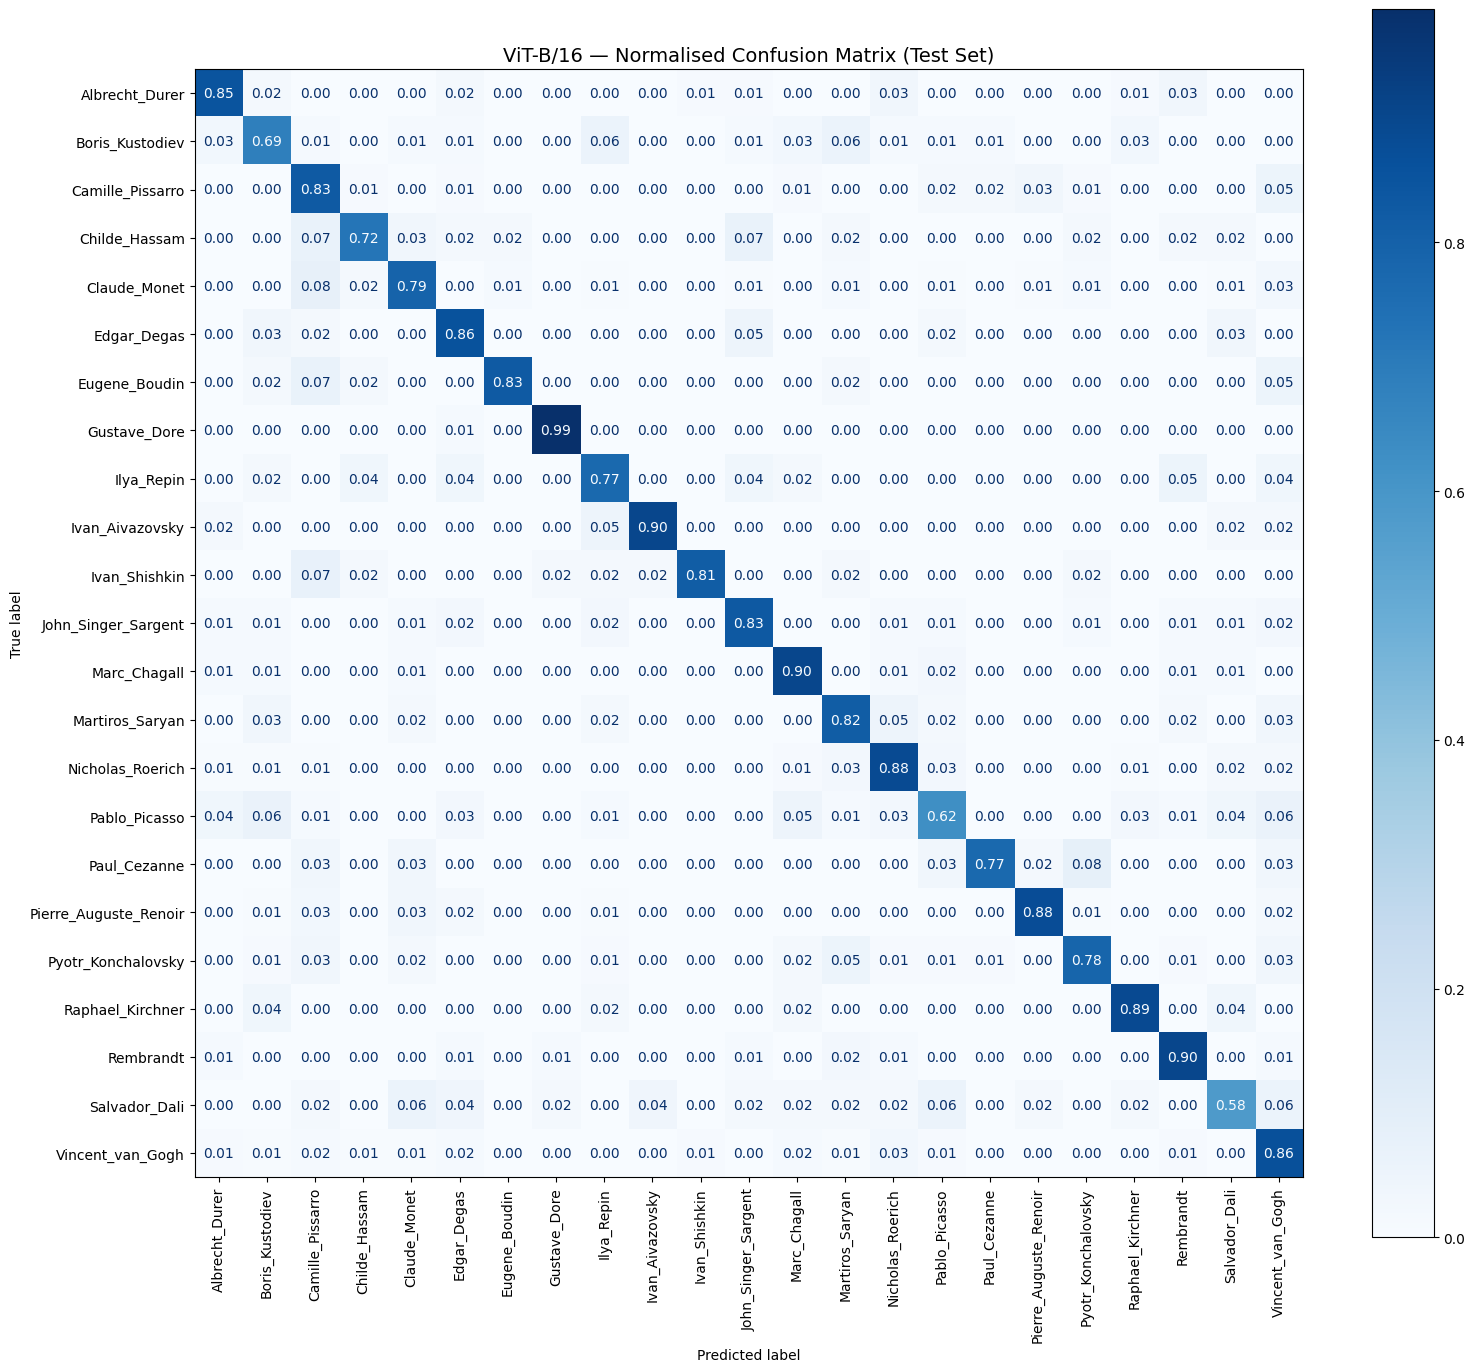

In [6]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=artist_names)
disp.plot(ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=90)
ax.set_title('ViT-B/16 — Normalised Confusion Matrix (Test Set)', fontsize=14)
plt.tight_layout()

os.makedirs('../results/figures', exist_ok=True)
save_path = '../results/figures/vit_confusion_matrix_normalised.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")
plt.show()

## 5. Per-class F1 Bar Chart
Visualise F1-score per artist to identify which classes the model handles well and where it struggles.

Figure saved to: ../results/figures/vit_per_class_f1.png


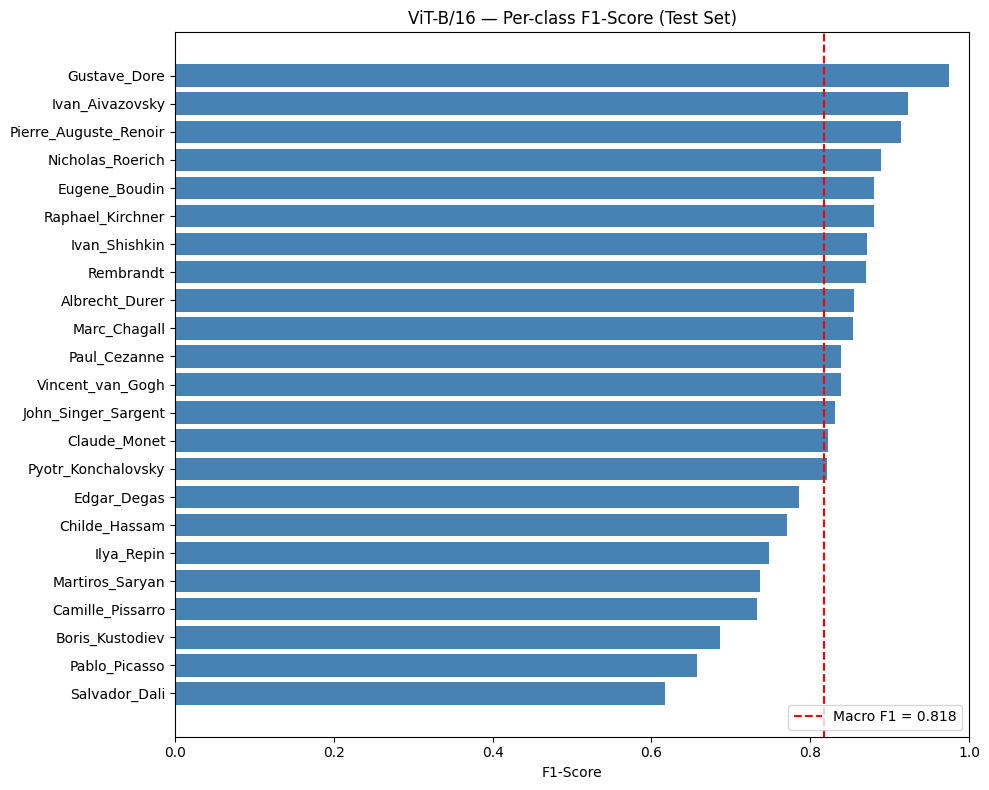

In [7]:
from sklearn.metrics import f1_score as sk_f1

per_class_f1 = sk_f1(y_true, y_pred, average=None)
macro_f1 = sk_f1(y_true, y_pred, average='macro')

# Sort by F1 for readability
sorted_idx = np.argsort(per_class_f1)
sorted_names = [artist_names[i] for i in sorted_idx]
sorted_f1 = per_class_f1[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(sorted_names, sorted_f1, color='steelblue')
ax.axvline(x=macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.3f}')
ax.set_xlabel('F1-Score')
ax.set_title('ViT-B/16 — Per-class F1-Score (Test Set)')
ax.set_xlim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()

save_path = '../results/figures/vit_per_class_f1.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")
plt.show()